In [2]:
import numpy as np
import h5py
import time

import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt
import matplotlib as mpl
from helpers.simulation import *
from helpers.qtransform import *
from helpers.config import *
from helpers.h5file_helpers import *

from scipy.stats import truncnorm
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
from skimage.feature import peak_local_max

from astropy.cosmology import Planck18, z_at_value
from astropy import units as u

from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

/opt/anaconda3/envs/gwaves_lisa_py311/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


## Single dataset

In [24]:
def get_better_samples(good_samples, bad_samples, nsamples):
    good_x, good_y = good_samples
    bad_x, bad_y = bad_samples

    all_x = np.concatenate([good_x, bad_x])
    all_y = np.concatenate([good_y, bad_y])

    X_good = np.column_stack((good_x, good_y))
    X_bad = np.column_stack((bad_x, bad_y))

    X = np.vstack((X_good, X_bad))
    y = np.hstack((np.ones(len(X_good)), np.zeros(len(X_bad))))

    clf = RandomForestClassifier(n_estimators=500, random_state=42)
    clf.fit(X, y)

    samples = []
    while len(samples) < nsamples:
        x = np.random.uniform(np.min(all_x), np.max(all_x), nsamples)
        y  = np.random.uniform(np.min(all_y), np.max(all_y), nsamples)

        X_new = np.column_stack((x, y))
        prob = clf.predict_proba(X_new)[:, 1]
        samples.extend(X_new[prob > 0.9])

    samples = np.vstack(samples)[:nsamples]
    return samples

In [7]:
def filter_by_snr(dataset_path, to_find=1, threshold=8):
    with h5py.File(dataset_path, 'r') as h5:
        t_qscan = h5['t_qscan'][:]
        f_qscan = h5['f_qscan'][:]
        qt = h5['QT'][:]
        tcen = h5['tcen'][:]

    idx = np.argmin(np.abs(tcen), axis=1)
    images = qt[np.arange(qt.shape[0]), idx]
    t_axes = t_qscan[np.arange(qt.shape[0]), idx]
    f_axes = f_qscan[np.arange(qt.shape[0]), idx]
    snrs = np.sqrt(images**2 - 1)

    good_idx = []
    for index in range(images.shape[0]):
        T_opt = []
        for j in range(snrs.shape[-1]):
            snr = snrs[index, :, :, j]
            t_axis = t_axes[index, :, j]
            f_axis = f_axes[index, :, j]
            _, T_grid = np.meshgrid(f_axis, t_axis, indexing="ij")

            T_opt.append(T_grid[snr > threshold])
        
        T_opt = np.concatenate(T_opt)/3600
        if len(T_opt) < 2:
            if to_find == 0:
                good_idx.append(index)
            continue
        try:
            times = np.linspace(np.min(t_axes[index])/3600, np.max(t_axes[index])/3600, 250)
            pdf = gaussian_kde(T_opt)(times)
            peaks, _ = find_peaks(pdf, width=1, prominence=0.05)

            if len(peaks) >= to_find:
                good_idx.append(index)
        except Exception as e:
            print(f"Sample {index}: {e}")

    return np.array(good_idx)

In [8]:
good_idx = filter_by_snr(gw_testset_path, to_find=1, threshold=8)

In [3]:
gw_dict = {}
with h5py.File(gw_dataset_path, 'r+') as h5:
    for key in list(h5.keys()):
        gw_dict[key] = h5[key][:]

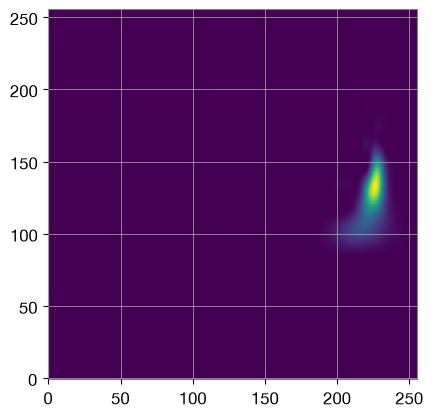

In [8]:
image = gw_dict['QT'][1050, 2, : ,:, 0]
plt.imshow(image, origin='lower')

In [13]:
tdi_dict = {'X': gw_dict['X'], 'Y': gw_dict['Y'], 'Z': gw_dict['Z']}
h5 = h5py.File(gw_dataset_path, 'a')
append_gw_sample(h5, tdi_dict=tdi_dict, m1=gw_dict['m1'], m2=gw_dict['m2'],
                  d=gw_dict['d'], spin1=gw_dict['spin1'], spin2=gw_dict['spin2'],
                  iota=gw_dict['iota'], gw_beta=gw_dict['gw_beta'], 
                  gw_lambda=gw_dict['gw_lambda'], t0=gw_dict['t0'])
append_image(h5, image=gw_dict['QT'], t_arr=gw_dict['t_qscan'],
              f_arr=gw_dict['f_qscan'], tcen=gw_dict['tcen'], keys=['QT', 't_qscan', 'f_qscan'])
h5.close()

In [14]:
good_idx = filter_by_snr(glitch_testset_path, to_find=1, threshold=8)

In [ ]:
glitch_dict = {}
with h5py.File(glitch_dataset_path, 'r+') as h5:
    for key in list(h5.keys()):
        glitch_dict[key] = h5[key][good_idx]

In [16]:
tdi_dict = {'X': glitch_dict['X'], 'Y': glitch_dict['Y'], 'Z': glitch_dict['Z']}
h5 = h5py.File(glitch_dataset_path, 'a')
append_glitch_sample(h5, tdi_dict=tdi_dict, amp=glitch_dict['amp'],
                     beta=glitch_dict['beta'], inj_point=glitch_dict['inj_point'],
                     t0=glitch_dict['t0'])
append_image(h5, image=glitch_dict['QT'], t_arr=glitch_dict['t_qscan'],
              f_arr=glitch_dict['f_qscan'], tcen=glitch_dict['tcen'],
                keys=['QT', 't_qscan', 'f_qscan'])
h5.close()

In [ ]:
from joblib import load

nsamples = 1000
samples = []
glitch_forest_path = str(GLITCH_DATASETS / 'glitch_random_forest.joblib')
clf = load(glitch_forest_path)
while len(samples) < nsamples:
    x = np.random.uniform(0, 3+np.log10(5), nsamples)
    y  = np.random.uniform(-14, -11, nsamples)

    X_new = np.column_stack((x, y))
    prob = clf.predict_proba(X_new)[:, 1]
    samples.extend(X_new[prob > 0.9])

samples = np.vstack(samples)[:nsamples]
amp_new = 10**samples[:,1]
beta_new = 10**samples[:,0]

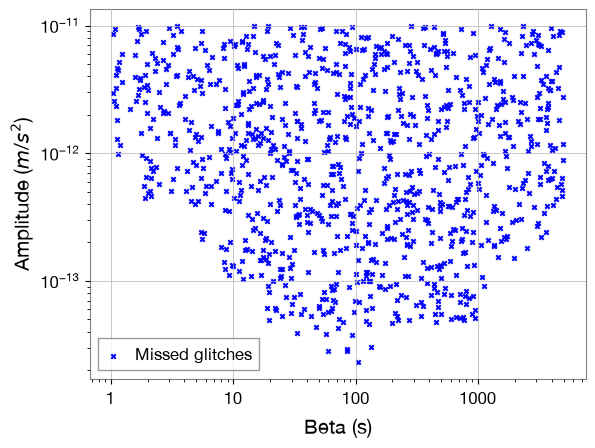

In [29]:
plt.scatter(beta_new, amp_new, color='blue', s=10, marker='x', label='Missed glitches')

plt.xlabel('Beta (s)')
plt.ylabel('Amplitude ($m$/$s^2$)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

In [31]:
nsamples = 1000
samples = []
gw_forest_path = str(GW_DATASETS / 'gw_random_forest.joblib')
clf = load(gw_forest_path)
while len(samples) < nsamples:
    x = np.random.uniform(3, 5, nsamples)
    y = np.random.uniform(4, 7, nsamples)

    X_new = np.column_stack((x, y))
    prob = clf.predict_proba(X_new)[:, 1]
    samples.extend(X_new[prob > 0.9])

samples = np.vstack(samples)[:nsamples]
Mc_new = 10**samples[:,1]
d_new = 10**samples[:,0]

In [56]:
with h5py.File(gw_dataset_path, 'r') as h5:
    m1_arr = h5['m1'][:]
    m2_arr = h5['m2'][:]
    d_arr = h5['d'][:]

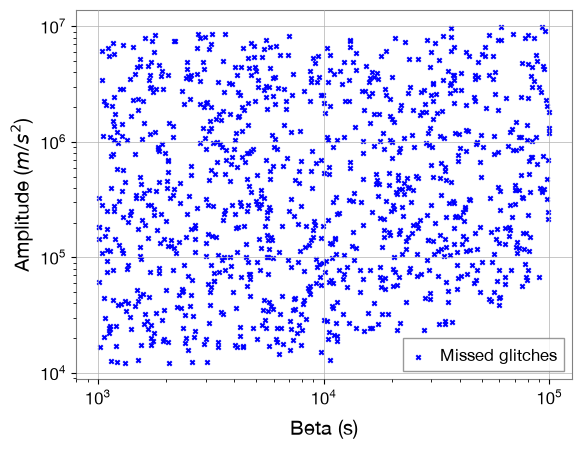

In [57]:
Mc_arr = chirp_mass(m1_arr, m2_arr)
plt.scatter(d_arr, Mc_arr, color='blue', s=10, marker='x', label='Missed glitches')

plt.xlabel('Beta (s)')
plt.ylabel('Amplitude ($m$/$s^2$)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

In [11]:
with h5py.File(mixed_dataset_path, 'r+') as h5:
    images = h5['QT'][:]

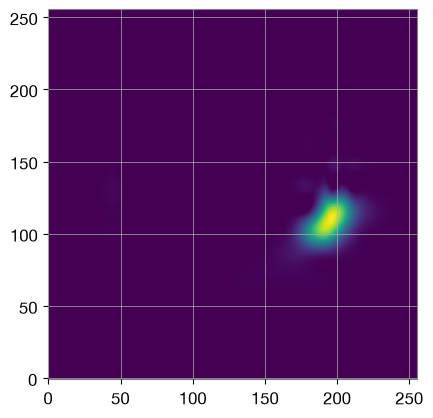

In [31]:
idx = 1221
image = images[idx, 2, :, :, :] 
plt.imshow(image[:,:,0], origin='lower')
plt.show()